In [7]:
import pandas as pd

In [10]:
df = pd.read_csv("Mall_Customers.csv")

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [12]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [15]:
df_numeric = df.drop(columns=['CustomerID'], errors='ignore')
df_numeric = df_numeric.select_dtypes(include=[np.number])

# Correlation Heatmap

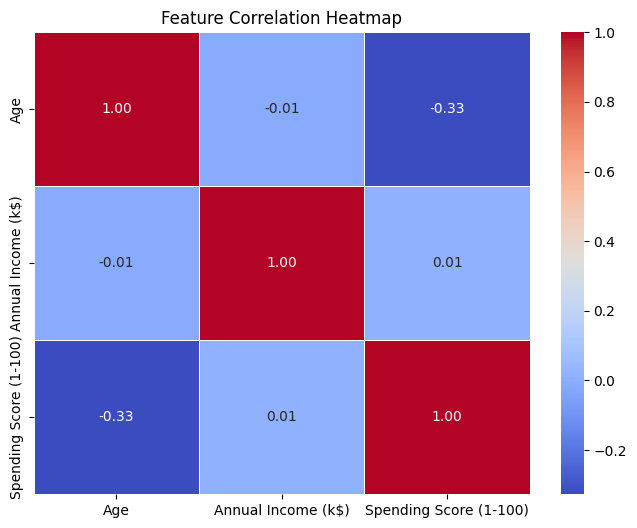

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# K-Means Model

In [17]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Cluster Scatter Plot

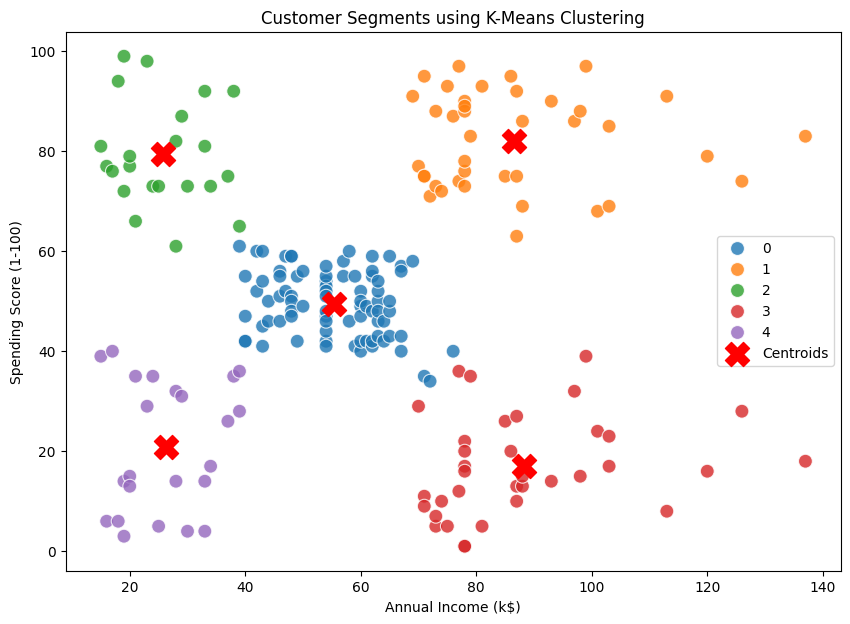

In [18]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster', 
    data=df, 
    palette='tab10', 
    s=100, 
    alpha=0.8
)

plt.scatter(
    kmeans.cluster_centers_[:, 0], 
    kmeans.cluster_centers_[:, 1], 
    s=300, 
    c='red', 
    marker='X', 
    label='Centroids'
)

plt.title('Customer Segments using K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [19]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,1.400000
std,57.879185,13.969007,26.264721,25.823522,1.449311
min,1.000000,18.000000,15.000000,1.000000,0.000000
25%,50.750000,28.750000,41.500000,34.750000,0.000000
50%,100.500000,36.000000,61.500000,50.000000,1.000000
75%,150.250000,49.000000,78.000000,73.000000,3.000000
max,200.000000,70.000000,137.000000,99.000000,4.000000


# Elbow Method
Within-Cluster Sum of Squares (WCSS)

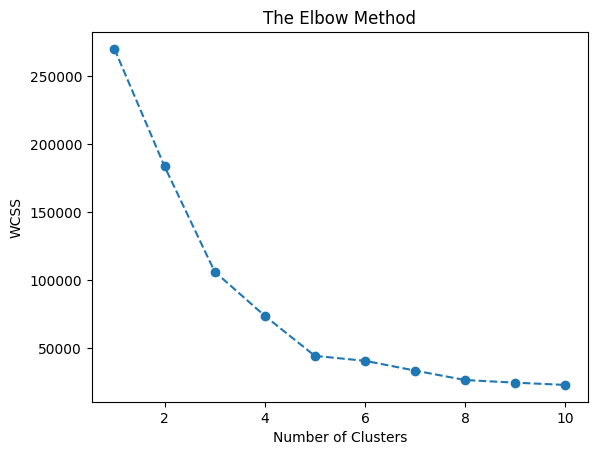

In [20]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [21]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Standard K-Means (Random Initialization) 

In [22]:
kmeans_random = KMeans(n_clusters=5, init='random', max_iter=300, random_state=42)
df['Cluster_Random'] = kmeans_random.fit_predict(X)

print(f"Standard K-Means Converged in: {kmeans_random.n_iter_} iterations")
print(f"Standard K-Means WCSS (Inertia): {kmeans_random.inertia_:.2f}")

Standard K-Means Converged in: 9 iterations
Standard K-Means WCSS (Inertia): 44448.46


# K-Means++ (Smart Initialization)

In [23]:
kmeans_pp = KMeans(n_clusters=5, init='k-means++', max_iter=300, random_state=42)
df['Cluster_PP'] = kmeans_pp.fit_predict(X)

print(f"K-Means++ Converged in: {kmeans_pp.n_iter_} iterations")
print(f"K-Means++ WCSS (Inertia): {kmeans_pp.inertia_:.2f}")

K-Means++ Converged in: 4 iterations
K-Means++ WCSS (Inertia): 44448.46


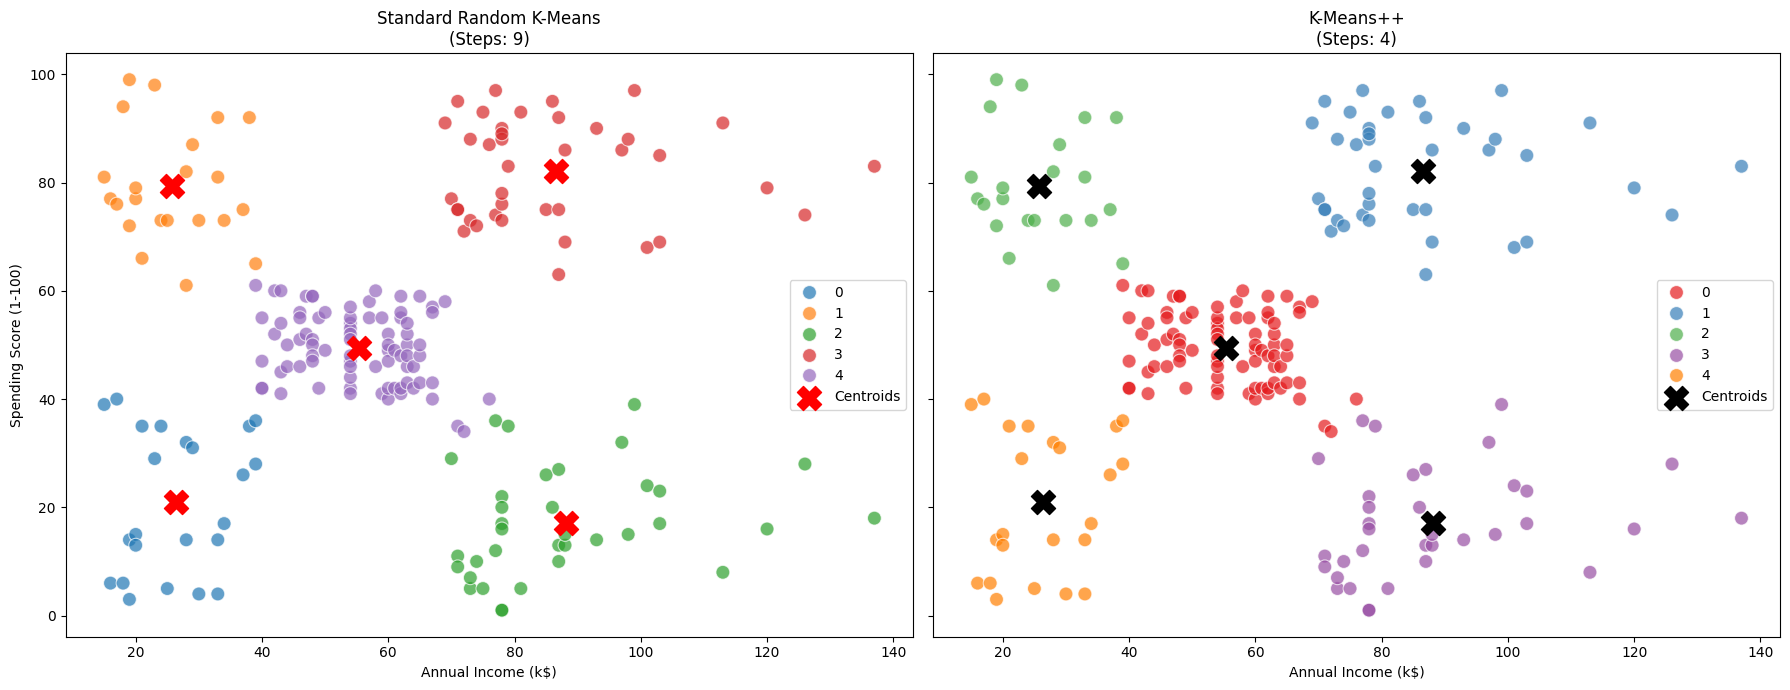

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

sns.scatterplot(
    x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster_Random', 
    data=df, palette='tab10', s=100, alpha=0.7, ax=axes[0]
)
axes[0].scatter(kmeans_random.cluster_centers_[:, 0], kmeans_random.cluster_centers_[:, 1], 
                s=300, c='red', marker='X', label='Centroids')
axes[0].set_title(f'Standard Random K-Means\n(Steps: {kmeans_random.n_iter_})')
axes[0].legend()

sns.scatterplot(
    x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster_PP', 
    data=df, palette='Set1', s=100, alpha=0.7, ax=axes[1]
)
axes[1].scatter(kmeans_pp.cluster_centers_[:, 0], kmeans_pp.cluster_centers_[:, 1], 
                s=300, c='black', marker='X', label='Centroids')
axes[1].set_title(f'K-Means++\n(Steps: {kmeans_pp.n_iter_})')
axes[1].legend()

plt.tight_layout()
plt.show()

# Silhouette Score
 measures how close each point is to its own cluster compared to other clusters. It ranges from -1 to +1.

In [25]:
from sklearn.metrics import silhouette_score
sil_random = silhouette_score(X, kmeans_random.labels_)
sil_pp = silhouette_score(X, kmeans_pp.labels_)

print("--- Silhouette Score Evaluation ---")
print(f"Standard K-Means Silhouette Score: {sil_random:.4f}")
print(f"K-Means++ Silhouette Score:      {sil_pp:.4f}")

--- Silhouette Score Evaluation ---
Standard K-Means Silhouette Score: 0.5539
K-Means++ Silhouette Score:      0.5539


# Calinski-Harabasz Index (Variance Ratio)
 metric evaluates clusters based on the ratio of the sum of between-clusters variance to within-cluster variance. A higher score means better defined and more separated clusters.

In [27]:
from sklearn.metrics import calinski_harabasz_score

ch_random = calinski_harabasz_score(X, kmeans_random.labels_)
ch_pp = calinski_harabasz_score(X, kmeans_pp.labels_)

print(f"Standard K-Means CH Score: {ch_random:.2f}")
print(f"K-Means++ CH Score:      {ch_pp:.2f}")

Standard K-Means CH Score: 247.36
K-Means++ CH Score:      247.36


# Plotting a Silhouette Analysis Diagram (Advanced Visual Evaluation)

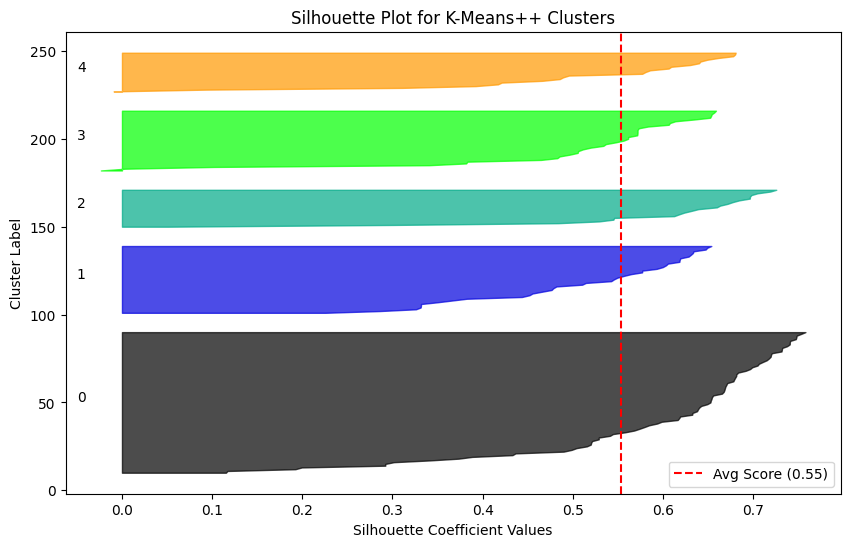

In [28]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

cluster_labels = kmeans_pp.labels_
sample_silhouette_values = silhouette_samples(X, cluster_labels)

fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))
y_lower = 10

for i in range(5): # Loop through our 5 clusters
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / 5)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10  # 10 for the 0 samples gap

ax1.set_title("Silhouette Plot for K-Means++ Clusters")
ax1.set_xlabel("Silhouette Coefficient Values")
ax1.set_ylabel("Cluster Label")

ax1.axvline(x=sil_pp, color="red", linestyle="--", label=f"Avg Score ({sil_pp:.2f})")
ax1.legend()
plt.show()